# Category Intelligence — Retail Product Performance EDA
**Calibo AI Academy · Path 2, KLU Batch · Phase 1, Mini Use Case 01**

**Analyst:** [Your Name]
**Dataset:** `MUC01_Retail_Sales_Dataset.csv` (Jan–Jun 2026, 12 stores, 6 cities, 5 categories)
**Prepared for:** Category Manager — Quarterly Supplier Review

## CBIM Problem Canvas

| Canvas Element | Answer |
|---|---|
| **Situation (S)** | A regional retail chain runs 12 stores across 6 cities in Andhra Pradesh (Vijayawada, Guntur, Rajahmundry, Tirupati, Nellore, Kakinada), selling five product categories — Electronics, Apparel, Grocery, Home & Kitchen, and Personal Care. Six months of transaction-level sales data (Jan–Jun 2026, ~108K transactions) exists but has not yet been analysed to inform business decisions. |
| **Complication (C)** | The Category Manager has a quarterly supplier review next week where suppliers for each category will argue for continued or increased shelf space and promotional budget. She currently has no consolidated, data-backed view of which categories are actually growing versus declining, which products are carrying each category, or whether the discounts already being given are paying for themselves — so she risks negotiating from instinct rather than evidence. |
| **Question (Q)** | Based on the last six months of transaction data, which categories are growing or declining, which specific products are driving that performance, whether current discounting is generating incremental revenue or just eroding margin, and what one clear recommendation should the Category Manager carry into the supplier review — not "what does the data show" but "what should she do differently starting next quarter." |
| **SSOT** | `MUC01_Retail_Sales_Dataset.csv` — the transaction-level sales log (transaction_id, date, store, category, product, units_sold, unit_price, revenue, discount_pct) is the single source of truth for this analysis. No other data source (supplier contracts, footfall, inventory) is in scope for this mini use case. |
| **Success definition** | The analysis is useful if the Category Manager can walk into the supplier meeting and, without opening the notebook herself, state: (1) which category's trend is weakest and by how much, (2) which specific product/category she is prepared to challenge on renewal terms, (3) whether discounting is working, backed by a number, and (4) one thing she'd still want to know before finalising a decision. Every chart must support one of these four statements. |
| **Primary stakeholder** | The Category Manager. She needs a small set of clearly labelled, business-language charts and a short written briefing she can act on directly — not a technical notebook she has to interpret herself. |


## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

df = pd.read_csv("MUC01_Retail_Sales_Dataset.csv")
df["date"] = pd.to_datetime(df["date"])
df.head()

,transaction_id,date,store_id,store_city,category,product_name,units_sold,unit_price,revenue,discount_pct
0,TXN000001,2026-01-01,S01,Vijayawada,Electronics,Smart TV,2,"3,075.46","5,843.37",5
1,TXN000002,2026-01-01,S01,Vijayawada,Electronics,Laptop,1,"11,598.06","11,598.06",0
2,TXN000003,2026-01-01,S01,Vijayawada,Electronics,Tablet,3,"5,738.37","15,493.60",10
3,TXN000004,2026-01-01,S01,Vijayawada,Electronics,Smart TV,3,"3,281.28","9,351.65",5
4,TXN000005,2026-01-01,S01,Vijayawada,Apparel,Jeans,1,"1,917.14","1,917.14",0


## 6.1 Load and Inspect the Data

In [2]:
print("Shape (rows, columns):", df.shape)
print()
print("Data types:")
print(df.dtypes)
print()
print("Missing values per column:")
print(df.isnull().sum())

Shape (rows, columns): (107836, 10)

Data types:
transaction_id               str
date              datetime64[us]
store_id                     str
store_city                   str
category                     str
product_name                 str
units_sold                 int64
unit_price               float64
revenue                  float64
discount_pct               int64
dtype: object

Missing values per column:
transaction_id    0
date              0
store_id          0
store_city        0
category          0
product_name      0
units_sold        0
unit_price        0
revenue           0
discount_pct      0
dtype: int64


In [3]:
print("Unique categories:", df["category"].nunique(), "->", list(df["category"].unique()))
print("Unique products:", df["product_name"].nunique())
print("Unique stores:", df["store_id"].nunique(), "across", df["store_city"].nunique(), "cities")
print("Date range:", df["date"].min().date(), "to", df["date"].max().date())

Unique categories: 5 -> ['Electronics', 'Apparel', 'Grocery', 'Home & Kitchen', 'Personal Care']
Unique products: 25
Unique stores: 12 across 6 cities
Date range: 2026-01-01 to 2026-06-30


In [4]:
df.describe()

,date,units_sold,unit_price,revenue,discount_pct
count,107836,"107,836.00","107,836.00","107,836.00","107,836.00"
mean,2026-04-01 18:11:48.275529,2.58,"1,778.10","4,263.92",7.23
min,2026-01-01 00:00:00,1.00,50.02,40.04,0.00
25%,2026-02-15 00:00:00,1.00,274.83,467.77,0.00
50%,2026-04-02 00:00:00,2.00,488.45,"1,034.62",5.00
75%,2026-05-17 00:00:00,3.00,"1,039.52","2,473.34",10.00
max,2026-06-30 00:00:00,13.00,"44,990.14","355,090.88",20.00
std,NaN,1.47,"5,053.63","14,243.24",6.73


**Observations from `.describe()`:**

1. **Revenue is heavily right-skewed.** The mean transaction revenue (₹4,264) sits well above the median (₹1,035), and the standard deviation (₹14,243) is more than 3x the mean. A handful of high-ticket categories — Electronics in particular — are pulling the average up. This means any "average revenue" figure quoted to the Category Manager without a category breakdown will be misleading; the categories cannot be judged on one blended number.
2. **Unit price spans nearly a 900x range** (₹50 to ₹44,990), which confirms the dataset genuinely mixes low-value grocery/personal-care items with high-value electronics in the same table. Any cross-category comparison must be done on **revenue**, not units sold, or Grocery will look artificially competitive against Electronics simply because it moves more units at a much lower price point.
3. There are **no missing values** in any column, and the dataset spans exactly six months (Jan 1 – Jun 30, 2026) across all **5 categories**, **25 products** (5 per category), and **12 stores** in **6 cities** — the data is clean and complete enough to analyse directly without an imputation step.

## 6.2 Category Revenue Trend Over Time

In [5]:
df["month"] = df["date"].dt.to_period("M").dt.to_timestamp()

cat_month_revenue = (
    df.groupby(["month", "category"])["revenue"]
    .sum()
    .reset_index()
)

pivot = cat_month_revenue.pivot(index="month", columns="category", values="revenue")
pivot

category,Apparel,Electronics,Grocery,Home & Kitchen,Personal Care
month,,,,,
2026-01-01,"10,049,916.78","45,686,596.63","7,307,011.34","15,130,871.54","6,593,734.81"
2026-02-01,"9,510,938.10","38,988,602.50","6,534,957.35","13,006,413.31","5,792,754.97"
2026-03-01,"11,540,439.47","40,846,509.47","7,132,787.06","14,362,119.50","6,808,029.34"
2026-04-01,"11,681,806.66","37,092,265.09","7,047,399.58","13,431,147.66","6,417,868.13"
2026-05-01,"13,219,535.79","34,226,926.43","7,232,706.20","13,581,886.25","7,298,818.71"
2026-06-01,"13,476,952.88","29,686,824.81","7,047,719.23","12,333,283.07","6,737,354.12"


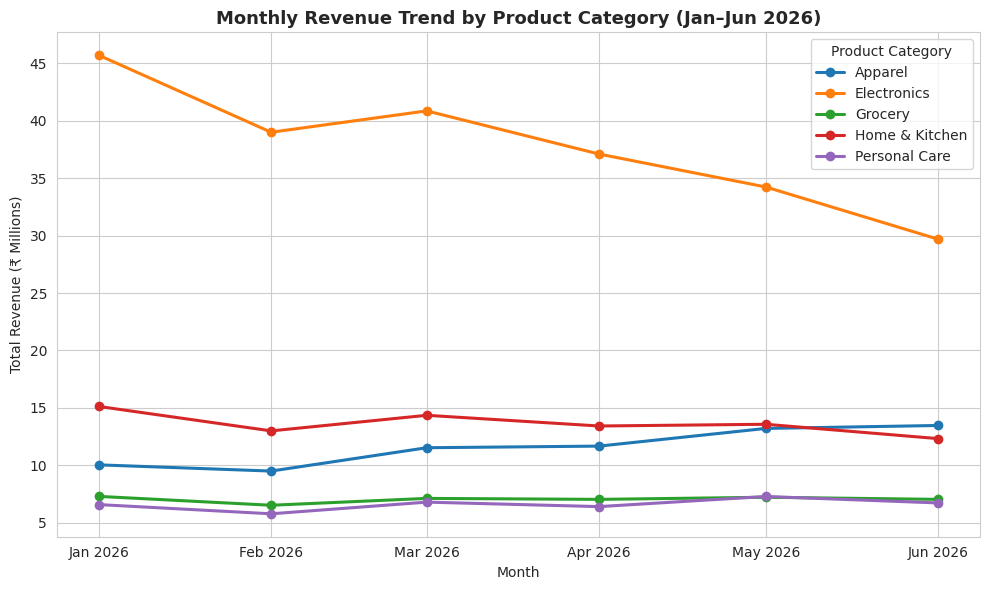

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

for category in pivot.columns:
    ax.plot(pivot.index, pivot[category] / 1e6, marker="o", linewidth=2.2, label=category)

ax.set_title("Monthly Revenue Trend by Product Category (Jan–Jun 2026)", fontsize=13, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Total Revenue (₹ Millions)")
ax.legend(title="Product Category", loc="upper right")
ax.set_xticks(pivot.index)
ax.set_xticklabels([d.strftime("%b %Y") for d in pivot.index], rotation=0)
plt.tight_layout()
plt.savefig("category_revenue_trend.png", dpi=150)
plt.show()

In [7]:
pct_change = ((pivot.iloc[-1] - pivot.iloc[0]) / pivot.iloc[0] * 100).sort_values()
volatility = (pivot.std() / pivot.mean() * 100).sort_values()

print("6-month % change by category (Jan -> Jun):")
print(pct_change.round(1))
print()
print("Month-to-month volatility (coefficient of variation, %):")
print(volatility.round(1))

6-month % change by category (Jan -> Jun):
category
Electronics      -35.00
Home & Kitchen   -18.50
Grocery           -3.50
Personal Care      2.20
Apparel           34.10
dtype: float64

Month-to-month volatility (coefficient of variation, %):
category
Grocery           3.90
Home & Kitchen    7.30
Personal Care     7.50
Apparel          13.90
Electronics      14.60
dtype: float64


**What this means for the Category Manager:**

**Electronics has the steepest decline** — down roughly **35% from January to June**, falling from ~₹45.7M to ~₹29.7M in monthly revenue, with the drop-off consistent almost every month rather than a single bad month. That is not noise; it is a trend, and it materially weakens the Electronics supplier's negotiating position for this review — the burden should be on them to explain the decline, not on the chain to justify continued shelf space.

**Grocery has been the most consistent performer** — its month-to-month revenue moves by less than 4% (lowest volatility of all five categories) and it closes the period down only marginally (~3.5%). It is not the biggest revenue category, but it is the most dependable one, which is a genuine asset when planning shelf space and staffing around predictable demand. Apparel, while it grew ~34% over the period, did so with much more month-to-month swing and should be watched rather than assumed to keep climbing at the same rate.

## 6.3 Top and Bottom Products by Category

In [8]:
product_revenue = (
    df.groupby(["category", "product_name"])["revenue"]
    .sum()
    .reset_index()
    .sort_values(["category", "revenue"], ascending=[True, False])
)

summary_rows = []
for category, group in product_revenue.groupby("category"):
    group_sorted = group.sort_values("revenue", ascending=False)
    top2 = group_sorted.head(2).assign(rank_label="Top")
    bottom2 = group_sorted.tail(2).assign(rank_label="Bottom")
    summary_rows.append(pd.concat([top2, bottom2]))

top_bottom_summary = pd.concat(summary_rows).reset_index(drop=True)
top_bottom_summary = top_bottom_summary[["category", "rank_label", "product_name", "revenue"]]
top_bottom_summary

,category,rank_label,product_name,revenue
0,Apparel,Top,Saree,"14,161,864.63"
1,Apparel,Top,T-Shirt,"14,099,251.65"
2,Apparel,Bottom,Formal Shirt,"13,748,976.91"
3,Apparel,Bottom,Kurta,"13,606,747.03"
4,Electronics,Top,Headphones,"47,696,053.99"
5,Electronics,Top,Laptop,"46,551,078.39"
6,Electronics,Bottom,Tablet,"44,744,388.93"
7,Electronics,Bottom,Smart TV,"41,882,166.21"
8,Grocery,Top,Rice (5kg),"8,562,171.86"
9,Grocery,Top,Dal (1kg),"8,488,303.64"


**Which supplier would I challenge, and why?**

Within every category, the spread between the top and bottom product is narrow — no single product is dramatically outperforming or underperforming its category peers (e.g. in Electronics, Headphones lead at ~₹47.7M and Smart TV trails at ~₹41.9M, a gap of about 12%, not a collapse). This tells the Category Manager something useful in itself: **product-level performance within a category is broadly balanced, so the real story is at the category level, not the product level.**

Given that, the category I would point to in the supplier review is still **Electronics** — not because one product is failing, but because *every* product in the category is being dragged down by the same category-wide 35% revenue decline identified in Step 6.2. That's a category-wide demand or pricing problem (worth asking the supplier about competitor pricing, stock-outs, or a stale product line-up), not a single weak SKU that can be swapped out. I would challenge the Electronics supplier specifically on **Smart TV and Tablet**, the two lowest revenue-contributors in the category, and ask them to justify continued shelf space for those two lines relative to the category's overall trajectory.

## 6.4 Discount Effectiveness Analysis

In [9]:
bins = [-1, 0, 5, 10, 15, 20, 100]
labels = ["0%", "1-5%", "6-10%", "11-15%", "16-20%", "21%+"]
df["discount_bracket"] = pd.cut(df["discount_pct"], bins=bins, labels=labels)

discount_summary = df.groupby("discount_bracket", observed=True).agg(
    avg_revenue_per_txn=("revenue", "mean"),
    avg_units_per_txn=("units_sold", "mean"),
    transaction_count=("transaction_id", "count"),
).round(2)

discount_summary

,avg_revenue_per_txn,avg_units_per_txn,transaction_count
discount_bracket,,,
0%,"4,685.65",2.59,36033
1-5%,"4,303.73",2.59,23922
6-10%,"4,005.55",2.57,23810
11-15%,"4,069.16",2.60,11935
16-20%,"3,631.73",2.58,12136


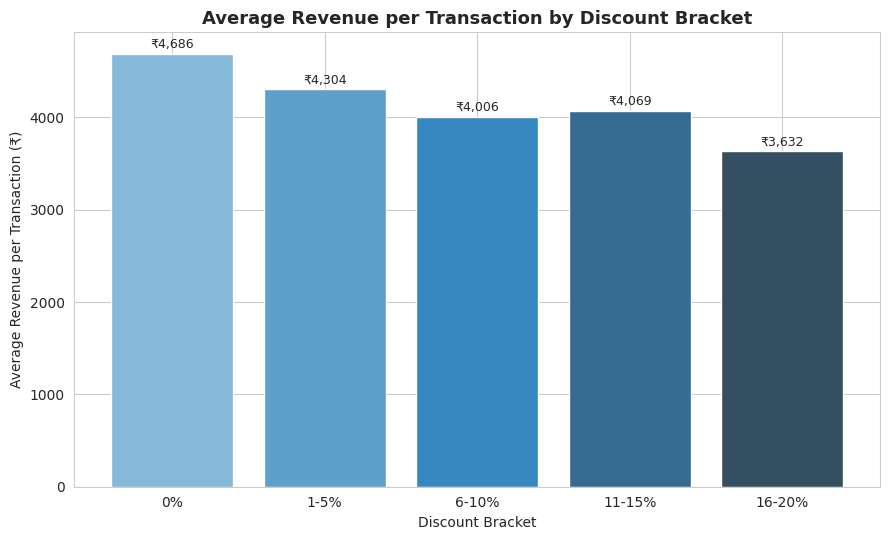

In [10]:
fig, ax = plt.subplots(figsize=(9, 5.5))

colors = sns.color_palette("Blues_d", n_colors=len(discount_summary))
bars = ax.bar(discount_summary.index.astype(str), discount_summary["avg_revenue_per_txn"], color=colors)

ax.set_title("Average Revenue per Transaction by Discount Bracket", fontsize=13, fontweight="bold")
ax.set_xlabel("Discount Bracket")
ax.set_ylabel("Average Revenue per Transaction (₹)")

for bar in bars:
    height = bar.get_height()
    ax.annotate(f"₹{height:,.0f}", xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 4), textcoords="offset points", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("discount_effectiveness.png", dpi=150)
plt.show()

**Position: discounts are not paying for themselves.**

Average revenue per transaction falls almost every time the discount bracket rises — from **₹4,686 at 0% discount down to ₹3,632 at 16-20% discount**, roughly a **22% drop in revenue per transaction** at the deepest discount level compared to no discount at all. Critically, **average units sold per transaction barely moves** across every bracket (holding steady between 2.57 and 2.60 units regardless of discount depth). That is the key signal: **deeper discounts are not persuading customers to buy meaningfully more — they are simply cutting the price on the same basket size.** The current discount strategy is eroding margin without a proportionate volume return, and I would recommend the Category Manager raise this directly with suppliers who are pushing for deeper promotional discounts as a condition of shelf space.

## 6.5 Day-of-Week and Monthly Patterns

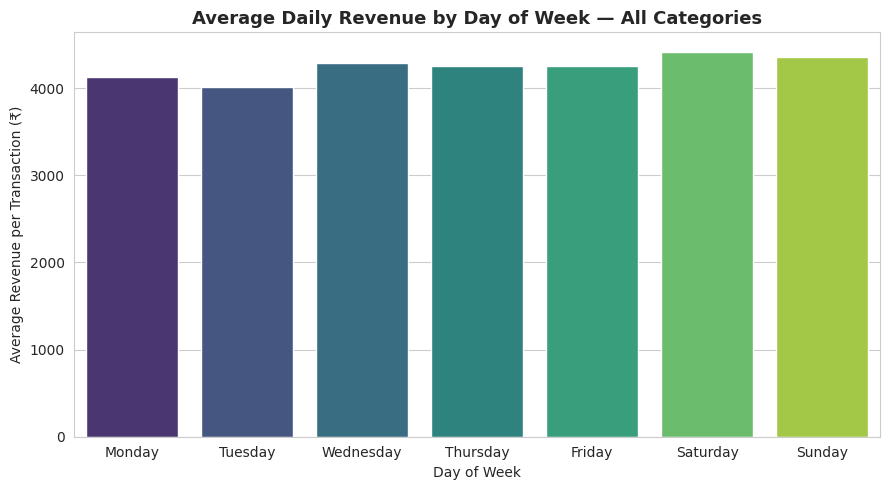

day_of_week
Monday      4,131.00
Tuesday     4,018.00
Wednesday   4,290.00
Thursday    4,255.00
Friday      4,256.00
Saturday    4,420.00
Sunday      4,352.00
Name: revenue, dtype: float64

In [11]:
df["day_of_week"] = df["date"].dt.day_name()
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

daily_avg = df.groupby("day_of_week")["revenue"].mean().reindex(day_order)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=daily_avg.index, y=daily_avg.values, hue=daily_avg.index, palette="viridis", legend=False, ax=ax)
ax.set_title("Average Daily Revenue by Day of Week — All Categories", fontsize=13, fontweight="bold")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Average Revenue per Transaction (₹)")
plt.tight_layout()
plt.savefig("dow_pattern.png", dpi=150)
plt.show()

daily_avg.round(0)

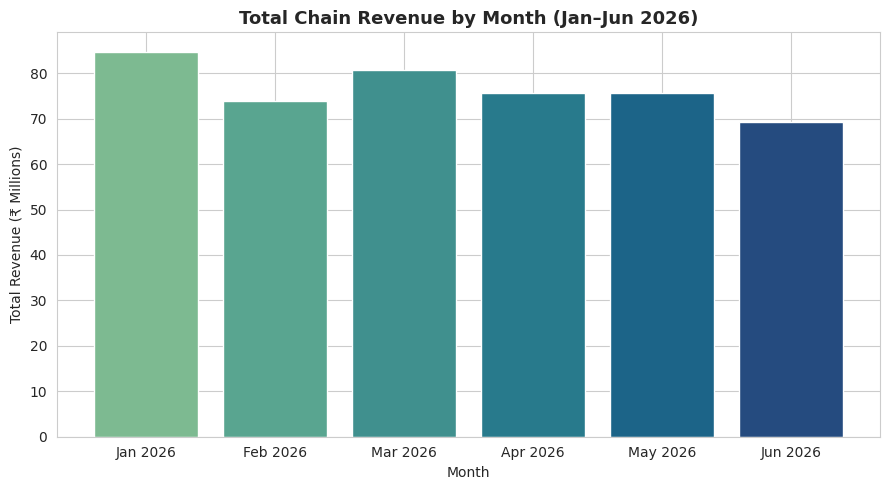

month
2026-01-01   84,768,131.00
2026-02-01   73,833,666.00
2026-03-01   80,689,885.00
2026-04-01   75,670,487.00
2026-05-01   75,559,873.00
2026-06-01   69,282,134.00
Name: revenue, dtype: float64

In [12]:
monthly_total = df.groupby("month")["revenue"].sum()

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(monthly_total.index.strftime("%b %Y"), monthly_total.values / 1e6, color=sns.color_palette("crest", len(monthly_total)))
ax.set_title("Total Chain Revenue by Month (Jan–Jun 2026)", fontsize=13, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Total Revenue (₹ Millions)")
plt.tight_layout()
plt.savefig("monthly_pattern.png", dpi=150)
plt.show()

monthly_total.round(0)

In [13]:
electronics = df[df["category"] == "Electronics"]
electronics_daily_avg = electronics.groupby("day_of_week")["revenue"].mean().reindex(day_order)

print("Chain-wide -> best day:", daily_avg.idxmax(), f"(₹{daily_avg.max():,.0f})",
      "| worst day:", daily_avg.idxmin(), f"(₹{daily_avg.min():,.0f})")
print("Chain-wide -> best month:", monthly_total.idxmax().strftime("%b %Y"), f"(₹{monthly_total.max()/1e6:,.1f}M)",
      "| worst month:", monthly_total.idxmin().strftime("%b %Y"), f"(₹{monthly_total.min()/1e6:,.1f}M)")
print()
print("Electronics -> best day:", electronics_daily_avg.idxmax(), f"(₹{electronics_daily_avg.max():,.0f})",
      "| worst day:", electronics_daily_avg.idxmin(), f"(₹{electronics_daily_avg.min():,.0f})")

Chain-wide -> best day: Saturday (₹4,420) | worst day: Tuesday (₹4,018)
Chain-wide -> best month: Jan 2026 (₹84.8M) | worst month: Jun 2026 (₹69.3M)

Electronics -> best day: Wednesday (₹59,127) | worst day: Tuesday (₹54,307)


**What this means for promotional timing:**

Chain-wide, **Saturday is the strongest day** and **Tuesday is the weakest**, and **January is the strongest month** while **June is the weakest** — consistent with the overall decline pattern seen in Step 6.2, since Electronics (the chain's largest category by revenue) has been sliding all six months. Electronics itself, however, **peaks on Wednesday rather than Saturday**, and is also weakest on Tuesday — a genuinely different pattern from the chain's weekend-driven rhythm. This matters for promotional timing: **weekend promotions make sense for the chain broadly, but if the Electronics supplier wants a promotional slot, a mid-week (Wednesday) push is where this category's own customers are already showing up, not Saturday** — running a generic weekend-only promotional calendar would under-serve Electronics' actual demand pattern.

## 6.6 Category Manager Briefing

**"Here's where we stand going into this review.** Apparel is the category I'd back for increased investment — revenue is up 34% since January and it's the only category still climbing, so it deserves more shelf space and promotional budget this quarter. On the other side, I'd challenge the **Electronics supplier** directly: category revenue has fallen from ₹45.7M to ₹29.7M since January, a **35% decline**, and it's not one bad product dragging it down — every product in the line-up is sliding with it, so I want them to explain what's driving that before we commit to renewal terms. On discounting: our data shows discounts aren't earning their keep — average revenue per transaction drops **22%** at 16-20% discount versus no discount, while units sold per transaction barely changes, so we should push back on suppliers who want deeper discounting as a condition of shelf space. Before I finalise anything, though, I'd want **margin/cost data by product**, not just revenue — a category can be declining in revenue but still be fine (or even improving) on margin, and I can't tell the difference from this dataset alone."**